Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DrishtiGS_Classified  resnet50_finetuned_distilled.pth	resnet50_improved.pth
resnet50_best.pth     resnet50_finetuned_drishti.pth


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/25 | Loss: 3.2713 | Train Acc: 0.6500 | Val Acc: 0.8000
✅ Model checkpoint saved.
Epoch 2/25 | Loss: 2.2667 | Train Acc: 0.7750 | Val Acc: 0.8000
Epoch 3/25 | Loss: 1.3549 | Train Acc: 0.9000 | Val Acc: 0.8000
Epoch 4/25 | Loss: 1.0738 | Train Acc: 0.9250 | Val Acc: 0.8000
Epoch 5/25 | Loss: 1.3163 | Train Acc: 0.9250 | Val Acc: 0.8000
Epoch 6/25 | Loss: 0.7084 | Train Acc: 0.9750 | Val Acc: 0.8000
Epoch 7/25 | Loss: 0.4367 | Train Acc: 1.0000 | Val Acc: 0.9000
✅ Model checkpoint saved.
Epoch 8/25 | Loss: 0.5776 | Train Acc: 0.9750 | Val Acc: 0.9000
Epoch 9/25 | Loss: 0.8302 | Train Acc: 0.9500 | Val Acc: 0.9000
Epoch 10/25 | Loss: 0.1619 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 11/25 | Loss: 0.1812 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 12/25 | Loss: 0.1633 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 13/25 | Loss: 0.1117 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 14/25 | Loss: 0.4829 | Train Acc: 0.9750 | Val Acc: 0.9000
Epoch 15/25 | Loss: 0.2548 | Train Acc: 1.0000 

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



🎯 Sample Predictions:
Glaucoma/drishtiGS_074.png: Glaucoma
Glaucoma/drishtiGS_071.png: Glaucoma
Glaucoma/drishtiGS_077.png: Glaucoma
Glaucoma/drishtiGS_079.png: Glaucoma
Glaucoma/drishtiGS_070.png: Glaucoma
Glaucoma/drishtiGS_087.png: Glaucoma
Glaucoma/drishtiGS_001.png: Glaucoma
Glaucoma/drishtiGS_050.png: Glaucoma
Glaucoma/drishtiGS_067.png: Glaucoma
Glaucoma/drishtiGS_055.png: Glaucoma

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.50      0.08      0.13        13
    Glaucoma       0.76      0.97      0.85        38

    accuracy                           0.75        51
   macro avg       0.63      0.53      0.49        51
weighted avg       0.69      0.75      0.67        51


✅ Accuracy: 74.51%


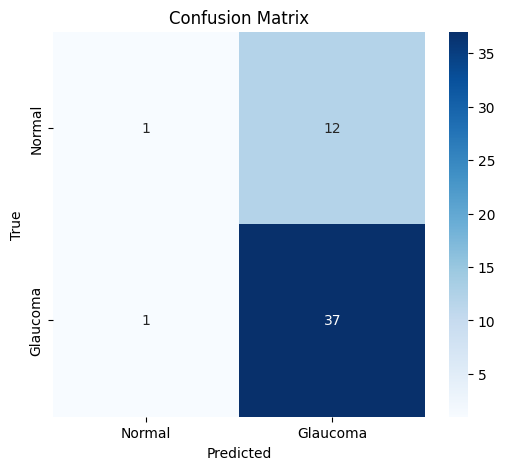

In [ ]:
# -*- coding: utf-8 -*-
"""Another copy of Test.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/11Sg6ih3NGjOuGxPQIwWEjwHRUmuAqCAi
"""

import os
import cv2
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.model_selection import train_test_split

# Config
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2"

DATA_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/DrishtiGS_Classified/Training"
BATCH_SIZE = 8
NUM_EPOCHS = 25
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Augmentation + Normalization
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Custom Dataset
class FundusDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

# Load data
def load_image_paths_and_labels(root_dir):
    image_paths, labels = [], []
    for label, folder in enumerate(["Normal", "Glaucoma"]):
        folder_path = os.path.join(root_dir, folder)
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(folder_path, file))
                labels.append(label)
    return image_paths, labels

img_paths, labels = load_image_paths_and_labels(DATA_PATH)
train_paths, val_paths, train_labels, val_labels = train_test_split(img_paths, labels, test_size=0.2, random_state=42)

train_dataset = FundusDataset(train_paths, train_labels, transform_train)
val_dataset = FundusDataset(val_paths, val_labels, transform_val)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Model setup
model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
model.fc = nn.Linear(model.fc.in_features, 2)
model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def evaluate_model():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

def train_model():
    best_acc = 0.0
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        scheduler.step()
        val_acc = evaluate_model()
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {running_loss:.4f} | Train Acc: {correct/total:.4f} | Val Acc: {val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/resnet50_finetuned_drishti.pth")
            print("✅ Model checkpoint saved.")

train_model()

import os
import cv2
import torch
import torchvision
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/DrishtiGS_Classified/Test"
MODEL_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/resnet50_finetuned_drishti.pth"
BATCH_SIZE = 8

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.img_paths, self.img_names = [], []
        self.transform = transform
        for subdir in os.listdir(root_dir):
            sub_path = os.path.join(root_dir, subdir)
            if os.path.isdir(sub_path):
                for file in os.listdir(sub_path):
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.img_paths.append(os.path.join(sub_path, file))
                        self.img_names.append(f"{subdir}/{file}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if self.transform:
            img = self.transform(img)
        return img, self.img_names[idx]

def load_model(model_path):
    model = models.resnet50(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

def test_model_on_dataset(model, data_loader):
    predictions, true_labels, pred_labels = [], [], []
    class_map = {"Normal": 0, "Glaucoma": 1}
    with torch.no_grad():
        for imgs, names in data_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            for name, pred in zip(names, preds):
                predictions.append((name, "Normal" if pred == 0 else "Glaucoma"))
                pred_labels.append(pred.item())
                true_labels.append(class_map[name.split("/")[0]])
    return predictions, true_labels, pred_labels

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

def main():
    test_dataset = TestDataset(TEST_PATH, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model = load_model(MODEL_PATH)
    results, true_labels, pred_labels = test_model_on_dataset(model, test_loader)

    print("\n🎯 Sample Predictions:")
    for name, pred in results[:10]:
        print(f"{name}: {pred}")

    print("\n📋 Classification Report:")
    print(classification_report(true_labels, pred_labels, target_names=["Normal", "Glaucoma"]))
    print(f"\n✅ Accuracy: {accuracy_score(true_labels, pred_labels)*100:.2f}%")

    plot_confusion_matrix(true_labels, pred_labels, ["Normal", "Glaucoma"])

if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DrishtiGS_Classified  resnet50_finetuned_distilled.pth	resnet50_improved.pth
resnet50_best.pth     resnet50_finetuned_drishti.pth


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


--- Starting Model Training ---
Epoch 1/15 | Loss: 0.6105 | Train Acc: 0.7000 | Val Acc: 0.6000
✅ Model checkpoint saved.
Epoch 2/15 | Loss: 0.4488 | Train Acc: 0.8500 | Val Acc: 0.7000
✅ Model checkpoint saved.
Epoch 3/15 | Loss: 0.2565 | Train Acc: 0.9500 | Val Acc: 0.7000
Epoch 4/15 | Loss: 0.2458 | Train Acc: 0.9250 | Val Acc: 0.7000
Epoch 5/15 | Loss: 0.1109 | Train Acc: 1.0000 | Val Acc: 0.7000
Epoch 6/15 | Loss: 0.0795 | Train Acc: 1.0000 | Val Acc: 0.8000
✅ Model checkpoint saved.
Epoch 7/15 | Loss: 0.1090 | Train Acc: 0.9750 | Val Acc: 0.8000
Epoch 8/15 | Loss: 0.1166 | Train Acc: 0.9500 | Val Acc: 0.7000
Epoch 9/15 | Loss: 0.1518 | Train Acc: 0.9500 | Val Acc: 0.8000
Epoch 10/15 | Loss: 0.1055 | Train Acc: 0.9750 | Val Acc: 0.8000
Epoch 11/15 | Loss: 0.0348 | Train Acc: 1.0000 | Val Acc: 0.6000
Epoch 12/15 | Loss: 0.0731 | Train Acc: 0.9750 | Val Acc: 0.6000
Epoch 13/15 | Loss: 0.2014 | Train Acc: 0.9250 | Val Acc: 0.6000
Epoch 14/15 | Loss: 0.0363 | Train Acc: 1.0000 | Val A

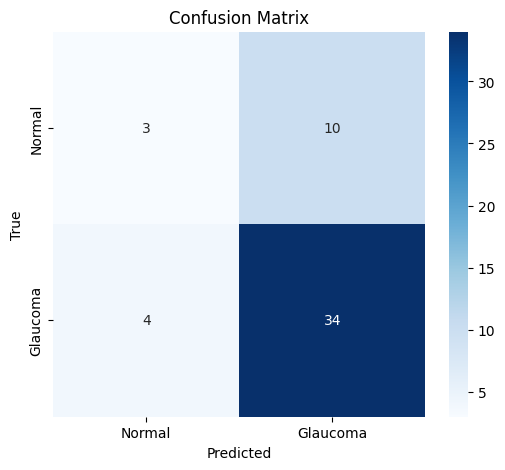

In [ ]:
# -*- coding: utf-8 -*-
"""Another copy of Test.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/11Sg6ih3NGjOuGxPQIwWEjwHRUmuAqCAi
"""

import os
import cv2
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# Config
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2"

DATA_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/DrishtiGS_Classified/Training"
TEST_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/DrishtiGS_Classified/Test"
MODEL_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/resnet50_finetuned_drishti.pth"
BATCH_SIZE = 8
# The number of epochs has been changed to 15 as requested.
NUM_EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Augmentation + Normalization for Training
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Normalization for Validation and Testing
transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Custom Dataset for Training/Validation
class FundusDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

# Custom Dataset for Testing
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.img_paths, self.img_names = [], []
        self.transform = transform
        # Assumes subdirectories are named 'Normal' and 'Glaucoma'
        for subdir in os.listdir(root_dir):
            sub_path = os.path.join(root_dir, subdir)
            if os.path.isdir(sub_path):
                for file in os.listdir(sub_path):
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.img_paths.append(os.path.join(sub_path, file))
                        # Store as 'subdir/file' for easy label extraction later
                        self.img_names.append(f"{subdir}/{file}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if self.transform:
            img = self.transform(img)
        return img, self.img_names[idx]


# Load data paths and labels
def load_image_paths_and_labels(root_dir):
    image_paths, labels = [], []
    class_map = {"Normal": 0, "Glaucoma": 1}
    for folder, label in class_map.items():
        folder_path = os.path.join(root_dir, folder)
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(folder_path, file))
                labels.append(label)
    return image_paths, labels

# Prepare datasets and dataloaders
img_paths, labels = load_image_paths_and_labels(DATA_PATH)
train_paths, val_paths, train_labels, val_labels = train_test_split(img_paths, labels, test_size=0.2, random_state=42, stratify=labels)

train_dataset = FundusDataset(train_paths, train_labels, transform_train)
val_dataset = FundusDataset(val_paths, val_labels, transform_val_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Model setup
model = models.resnet50(pretrained=True)
# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False
# Unfreeze later layers for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True
model.fc = nn.Linear(model.fc.in_features, 2) # 2 classes: Normal, Glaucoma
model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
# Optimize only the unfrozen layers
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# --- Training and Evaluation Functions ---
def evaluate_model(data_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

def train_model():
    best_acc = 0.0
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        train_acc = correct / total
        val_acc = evaluate_model(val_loader)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)
            print("✅ Model checkpoint saved.")

def test_model():
    # Load the best model
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    test_dataset = TestDataset(TEST_PATH, transform=transform_val_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    predictions, true_labels, pred_labels = [], [], []
    class_map = {"Normal": 0, "Glaucoma": 1}

    with torch.no_grad():
        for imgs, names in test_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            for name, pred in zip(names, preds):
                true_class_name = name.split("/")[0]
                pred_class_name = "Normal" if pred == 0 else "Glaucoma"
                predictions.append((name, pred_class_name))
                pred_labels.append(pred.item())
                true_labels.append(class_map[true_class_name])

    print("\n🎯 Sample Predictions:")
    for name, pred in predictions[:10]:
        print(f"{name}: {pred}")

    print("\n📋 Classification Report:")
    print(classification_report(true_labels, pred_labels, target_names=["Normal", "Glaucoma"]))
    print(f"\n✅ Accuracy: {accuracy_score(true_labels, pred_labels)*100:.2f}%")

    # Plotting confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Glaucoma"], yticklabels=["Normal", "Glaucoma"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

# --- Main Execution ---
if __name__ == "__main__":
    print("--- Starting Model Training ---")
    train_model()
    print("\n--- Starting Model Testing ---")
    test_model()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DrishtiGS_Classified  resnet50_finetuned_distilled.pth	resnet50_improved.pth
resnet50_best.pth     resnet50_finetuned_drishti.pth


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


--- Starting Model Training ---
Epoch 1/10 | Loss: 0.7492 | Train Acc: 0.4750 | Val Acc: 0.8000
✅ Model checkpoint saved.
Epoch 2/10 | Loss: 0.4505 | Train Acc: 0.7750 | Val Acc: 0.8000
Epoch 3/10 | Loss: 0.2815 | Train Acc: 0.9000 | Val Acc: 0.8000
Epoch 4/10 | Loss: 0.1797 | Train Acc: 0.9250 | Val Acc: 0.8000
Epoch 5/10 | Loss: 0.1828 | Train Acc: 0.9250 | Val Acc: 0.8000
Epoch 6/10 | Loss: 0.0617 | Train Acc: 1.0000 | Val Acc: 0.8000
Epoch 7/10 | Loss: 0.0511 | Train Acc: 1.0000 | Val Acc: 0.7000
Epoch 8/10 | Loss: 0.0913 | Train Acc: 0.9750 | Val Acc: 0.6000
Epoch 9/10 | Loss: 0.1109 | Train Acc: 0.9500 | Val Acc: 0.6000
Epoch 10/10 | Loss: 0.0485 | Train Acc: 1.0000 | Val Acc: 0.5000

--- Starting Model Testing ---

🎯 Sample Predictions:
Glaucoma/drishtiGS_074.png: Glaucoma
Glaucoma/drishtiGS_071.png: Normal
Glaucoma/drishtiGS_077.png: Glaucoma
Glaucoma/drishtiGS_079.png: Glaucoma
Glaucoma/drishtiGS_070.png: Glaucoma
Glaucoma/drishtiGS_087.png: Glaucoma
Glaucoma/drishtiGS_001.png

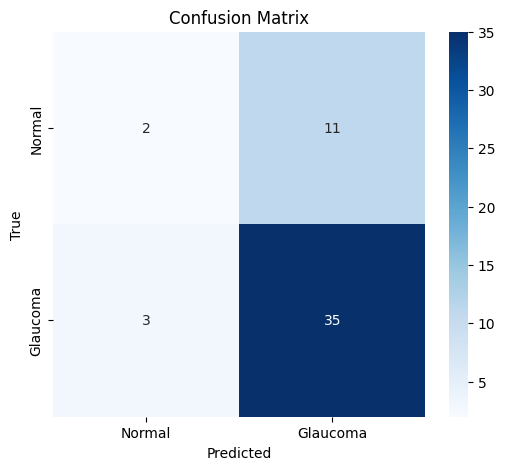

In [ ]:
# -*- coding: utf-8 -*-
"""Another copy of Test.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/11Sg6ih3NGjOuGxPQIwWEjwHRUmuAqCAi
"""

import os
import cv2
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# Config
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2"

DATA_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/DrishtiGS_Classified/Training"
TEST_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/DrishtiGS_Classified/Test"
MODEL_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/resnet50_finetuned_drishti.pth"
BATCH_SIZE = 8
# The number of epochs has been changed to 15 as requested.
NUM_EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Augmentation + Normalization for Training
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Normalization for Validation and Testing
transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Custom Dataset for Training/Validation
class FundusDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

# Custom Dataset for Testing
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.img_paths, self.img_names = [], []
        self.transform = transform
        # Assumes subdirectories are named 'Normal' and 'Glaucoma'
        for subdir in os.listdir(root_dir):
            sub_path = os.path.join(root_dir, subdir)
            if os.path.isdir(sub_path):
                for file in os.listdir(sub_path):
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.img_paths.append(os.path.join(sub_path, file))
                        # Store as 'subdir/file' for easy label extraction later
                        self.img_names.append(f"{subdir}/{file}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if self.transform:
            img = self.transform(img)
        return img, self.img_names[idx]


# Load data paths and labels
def load_image_paths_and_labels(root_dir):
    image_paths, labels = [], []
    class_map = {"Normal": 0, "Glaucoma": 1}
    for folder, label in class_map.items():
        folder_path = os.path.join(root_dir, folder)
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(folder_path, file))
                labels.append(label)
    return image_paths, labels

# Prepare datasets and dataloaders
img_paths, labels = load_image_paths_and_labels(DATA_PATH)
train_paths, val_paths, train_labels, val_labels = train_test_split(img_paths, labels, test_size=0.2, random_state=42, stratify=labels)

train_dataset = FundusDataset(train_paths, train_labels, transform_train)
val_dataset = FundusDataset(val_paths, val_labels, transform_val_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Model setup
model = models.resnet50(pretrained=True)
# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False
# Unfreeze later layers for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True
model.fc = nn.Linear(model.fc.in_features, 2) # 2 classes: Normal, Glaucoma
model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
# Optimize only the unfrozen layers
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# --- Training and Evaluation Functions ---
def evaluate_model(data_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

def train_model():
    best_acc = 0.0
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        train_acc = correct / total
        val_acc = evaluate_model(val_loader)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)
            print("✅ Model checkpoint saved.")

def test_model():
    # Load the best model
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    test_dataset = TestDataset(TEST_PATH, transform=transform_val_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    predictions, true_labels, pred_labels = [], [], []
    class_map = {"Normal": 0, "Glaucoma": 1}

    with torch.no_grad():
        for imgs, names in test_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            for name, pred in zip(names, preds):
                true_class_name = name.split("/")[0]
                pred_class_name = "Normal" if pred == 0 else "Glaucoma"
                predictions.append((name, pred_class_name))
                pred_labels.append(pred.item())
                true_labels.append(class_map[true_class_name])

    print("\n🎯 Sample Predictions:")
    for name, pred in predictions[:10]:
        print(f"{name}: {pred}")

    print("\n📋 Classification Report:")
    print(classification_report(true_labels, pred_labels, target_names=["Normal", "Glaucoma"]))
    print(f"\n✅ Accuracy: {accuracy_score(true_labels, pred_labels)*100:.2f}%")

    # Plotting confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Glaucoma"], yticklabels=["Normal", "Glaucoma"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

# --- Main Execution ---
if __name__ == "__main__":
    print("--- Starting Model Training ---")
    train_model()
    print("\n--- Starting Model Testing ---")
    test_model()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DrishtiGS_Classified  resnet50_finetuned_distilled.pth	resnet50_improved.pth
resnet50_best.pth     resnet50_finetuned_drishti.pth


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/50 | Loss: 3.1338 | Train Acc: 0.6750 | Val Acc: 0.8000
✅ Model checkpoint saved.
Epoch 2/50 | Loss: 2.2442 | Train Acc: 0.7500 | Val Acc: 0.8000
Epoch 3/50 | Loss: 1.3819 | Train Acc: 0.8750 | Val Acc: 0.8000
Epoch 4/50 | Loss: 1.5116 | Train Acc: 0.8750 | Val Acc: 0.8000
Epoch 5/50 | Loss: 1.7749 | Train Acc: 0.8750 | Val Acc: 0.8000
Epoch 6/50 | Loss: 0.5802 | Train Acc: 0.9500 | Val Acc: 0.8000
Epoch 7/50 | Loss: 0.7211 | Train Acc: 0.9750 | Val Acc: 0.8000
Epoch 8/50 | Loss: 0.6137 | Train Acc: 0.9750 | Val Acc: 0.8000
Epoch 9/50 | Loss: 0.4108 | Train Acc: 1.0000 | Val Acc: 0.8000
Epoch 10/50 | Loss: 0.3423 | Train Acc: 0.9750 | Val Acc: 0.8000
Epoch 11/50 | Loss: 0.3892 | Train Acc: 0.9750 | Val Acc: 0.9000
✅ Model checkpoint saved.
Epoch 12/50 | Loss: 0.3091 | Train Acc: 0.9750 | Val Acc: 0.9000
Epoch 13/50 | Loss: 0.3037 | Train Acc: 1.0000 | Val Acc: 0.8000
Epoch 14/50 | Loss: 0.1936 | Train Acc: 1.0000 | Val Acc: 0.8000
Epoch 15/50 | Loss: 0.2182 | Train Acc: 1.0000 

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



🎯 Sample Predictions:
Glaucoma/drishtiGS_074.png: Normal
Glaucoma/drishtiGS_071.png: Normal
Glaucoma/drishtiGS_077.png: Glaucoma
Glaucoma/drishtiGS_079.png: Normal
Glaucoma/drishtiGS_070.png: Normal
Glaucoma/drishtiGS_087.png: Glaucoma
Glaucoma/drishtiGS_001.png: Glaucoma
Glaucoma/drishtiGS_050.png: Glaucoma
Glaucoma/drishtiGS_067.png: Normal
Glaucoma/drishtiGS_055.png: Glaucoma

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.29      0.46      0.35        13
    Glaucoma       0.77      0.61      0.68        38

    accuracy                           0.57        51
   macro avg       0.53      0.53      0.51        51
weighted avg       0.64      0.57      0.59        51


✅ Accuracy: 56.86%


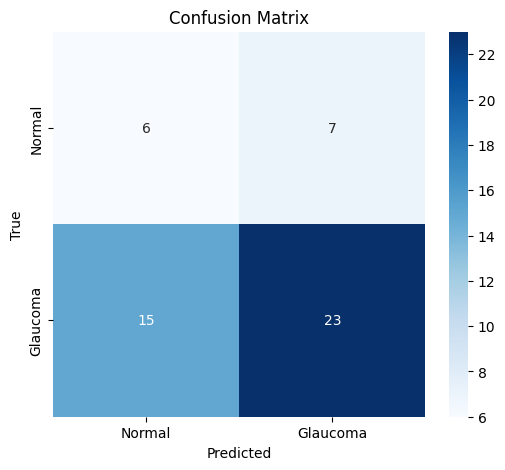

In [ ]:
# -*- coding: utf-8 -*-
"""Another copy of Test.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/11Sg6ih3NGjOuGxPQIwWEjwHRUmuAqCAi
"""

import os
import cv2
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.model_selection import train_test_split

# Config
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2"

DATA_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/DrishtiGS_Classified/Training"
BATCH_SIZE = 8
NUM_EPOCHS = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Augmentation + Normalization
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Custom Dataset
class FundusDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

# Load data
def load_image_paths_and_labels(root_dir):
    image_paths, labels = [], []
    for label, folder in enumerate(["Normal", "Glaucoma"]):
        folder_path = os.path.join(root_dir, folder)
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(folder_path, file))
                labels.append(label)
    return image_paths, labels

img_paths, labels = load_image_paths_and_labels(DATA_PATH)
train_paths, val_paths, train_labels, val_labels = train_test_split(img_paths, labels, test_size=0.2, random_state=42)

train_dataset = FundusDataset(train_paths, train_labels, transform_train)
val_dataset = FundusDataset(val_paths, val_labels, transform_val)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Model setup
model = models.resnet50(pretrained=True)
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
model.fc = nn.Linear(model.fc.in_features, 2)
model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def evaluate_model():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

def train_model():
    best_acc = 0.0
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        scheduler.step()
        val_acc = evaluate_model()
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {running_loss:.4f} | Train Acc: {correct/total:.4f} | Val Acc: {val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/resnet50_finetuned_drishti.pth")
            print("✅ Model checkpoint saved.")

train_model()

import os
import cv2
import torch
import torchvision
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/DrishtiGS_Classified/Test"
MODEL_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/resnet50_finetuned_drishti.pth"
BATCH_SIZE = 8

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.img_paths, self.img_names = [], []
        self.transform = transform
        for subdir in os.listdir(root_dir):
            sub_path = os.path.join(root_dir, subdir)
            if os.path.isdir(sub_path):
                for file in os.listdir(sub_path):
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.img_paths.append(os.path.join(sub_path, file))
                        self.img_names.append(f"{subdir}/{file}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if self.transform:
            img = self.transform(img)
        return img, self.img_names[idx]

def load_model(model_path):
    model = models.resnet50(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

def test_model_on_dataset(model, data_loader):
    predictions, true_labels, pred_labels = [], [], []
    class_map = {"Normal": 0, "Glaucoma": 1}
    with torch.no_grad():
        for imgs, names in data_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            for name, pred in zip(names, preds):
                predictions.append((name, "Normal" if pred == 0 else "Glaucoma"))
                pred_labels.append(pred.item())
                true_labels.append(class_map[name.split("/")[0]])
    return predictions, true_labels, pred_labels

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

def main():
    test_dataset = TestDataset(TEST_PATH, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model = load_model(MODEL_PATH)
    results, true_labels, pred_labels = test_model_on_dataset(model, test_loader)

    print("\n🎯 Sample Predictions:")
    for name, pred in results[:10]:
        print(f"{name}: {pred}")

    print("\n📋 Classification Report:")
    print(classification_report(true_labels, pred_labels, target_names=["Normal", "Glaucoma"]))
    print(f"\n✅ Accuracy: {accuracy_score(true_labels, pred_labels)*100:.2f}%")

    plot_confusion_matrix(true_labels, pred_labels, ["Normal", "Glaucoma"])

if __name__ == "__main__":
    main()

In [ ]:
# -*- coding: utf-8 -*-
"""Another copy of Test.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/11Sg6ih3NGjOuGxPQIwWEjwHRUmuAqCAi
"""

import os
import cv2
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import timm

# Config
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2"

DATA_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/DrishtiGS_Classified/Training"
TEST_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/DrishtiGS_Classified/Test"
MODEL_PATH = "/content/drive/MyDrive/Glucoma/DrishtiGS_Classified2/vit_finetuned_drishti.pth"
BATCH_SIZE = 8
NUM_EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Augmentation + Normalization
# Using the default ViT image size and normalization
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])
transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])


# Custom Dataset
class FundusDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

# Load data
def load_image_paths_and_labels(root_dir):
    image_paths, labels = [], []
    for label, folder in enumerate(["Normal", "Glaucoma"]):
        folder_path = os.path.join(root_dir, folder)
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(folder_path, file))
                labels.append(label)
    return image_paths, labels

img_paths, labels = load_image_paths_and_labels(DATA_PATH)
train_paths, val_paths, train_labels, val_labels = train_test_split(img_paths, labels, test_size=0.2, random_state=42)

train_dataset = FundusDataset(train_paths, train_labels, transform_train)
val_dataset = FundusDataset(val_paths, val_labels, transform_val_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Model setup using Vision Transformer
# Load a pretrained Vision Transformer model
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
model.to(DEVICE)

# Freeze all parameters initially
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the head for fine-tuning
for param in model.head.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
# Optimize only the parameters that require gradients
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def evaluate_model():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

def train_model():
    best_acc = 0.0
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        scheduler.step()
        val_acc = evaluate_model()
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {running_loss:.4f} | Train Acc: {correct/total:.4f} | Val Acc: {val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)
            print("✅ Model checkpoint saved.")

train_model()


class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.img_paths, self.img_names = [], []
        self.transform = transform
        for subdir in os.listdir(root_dir):
            sub_path = os.path.join(root_dir, subdir)
            if os.path.isdir(sub_path):
                for file in os.listdir(sub_path):
                    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.img_paths.append(os.path.join(sub_path, file))
                        self.img_names.append(f"{subdir}/{file}")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if self.transform:
            img = self.transform(img)
        return img, self.img_names[idx]

def load_model(model_path):
    # Re-create the model structure
    model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

def test_model_on_dataset(model, data_loader):
    predictions, true_labels, pred_labels = [], [], []
    class_map = {"Normal": 0, "Glaucoma": 1}
    with torch.no_grad():
        for imgs, names in data_loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            for name, pred in zip(names, preds):
                predictions.append((name, "Normal" if pred == 0 else "Glaucoma"))
                pred_labels.append(pred.item())
                true_labels.append(class_map[name.split("/")[0]])
    return predictions, true_labels, pred_labels

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

def main():
    test_dataset = TestDataset(TEST_PATH, transform=transform_val_test)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model = load_model(MODEL_PATH)
    results, true_labels, pred_labels = test_model_on_dataset(model, test_loader)

    print("\n🎯 Sample Predictions:")
    for name, pred in results[:10]:
        print(f"{name}: {pred}")

    print("\n📋 Classification Report:")
    print(classification_report(true_labels, pred_labels, target_names=["Normal", "Glaucoma"]))
    print(f"\n✅ Accuracy: {accuracy_score(true_labels, pred_labels)*100:.2f}%")

    plot_confusion_matrix(true_labels, pred_labels, ["Normal", "Glaucoma"])

if __name__ == "__main__":
    main()

KeyboardInterrupt: 